# Bicycle model
---

*Narcís Palomeras - September 2022 - Universitat de Girona (all rights reserved)*

**This project belongs to the Universitat de Girona. It is forbidden to publish this project or any derivative work in any public repository.**

---

Fill in the names of the group members:

#### Name = $\color{red}{\text{ Pravin Oli [u1999699]}}$


---

This lab is about kinematic motion models and basic motion controllers. It is divided in three parts:

* The Bicycle model
* Moving to a point ($x$, $y$)
* Move to a pose ($x$, $y$, $\theta$)

## Bicycle model

The bicycle model is a simplification of the popular *Ackerman* model used by cars. It is described by the following figure ([source](https://link.springer.com/book/10.1007/978-3-642-20144-8)):

<img src="http://eia.udg.edu/~npalomer/imgs/as/bicycle_model.png" width=450/>

The state of a *bicycle* is represented by:

$$
q = [x~y~\theta]
$$

where:

* $x$: is the $x$ position of the bicycle wrt. the world frame.
* $y$: is the $y$ position of the bicycle wrt. the world frame.
* $\theta$: is the orientation of the bicycle wrt. the world frame.

Because we are modelling a kinematic model, you do not have to include velocities in the state. However, let's define them:

* $v$: is the linear of the bicycle wrt. the bicycle frame.
* $w$: is the angular velocity of the bicycle, being $w = \dot{\theta}$.

The linear velocity measured in the vehicle frame is:

$$
^V{}\dot{x} = \nu, ~ ^V{}\dot{y} = 0
$$

The bicycle model has 2 control inputs:

* Desired velocity ($\nu_d$)
* Desired steering angle ($\gamma_d$)

## Pre-lab


> **Exercise**: To measure the turnning speed we need to compute first the *turning radius*. Looking at the figure above, measure the *turning radius* ($R_{1}$) using only the steering angle ($\gamma$) and the wheel base ($L$). Once you know the turning radius ($R_1$) you can compute the angular velocity $\dot{\theta}$ using the turning radius $R_1$ and the forward velocity $\nu$.


$\color{red}{\text{ANSWER=>}}$

To measure turning radius($R_{1})$:

$\color{blue}{\text{Given that;}}$\
steering angle=($\gamma$)\
wheel base=($L$)



$\color{blue}{\text{Here is the Equation;}}$\
turning radius ($R_{1}$) = $\frac{(L)}{Tan(\gamma)}$

In [5]:
import math
def r_1(gamma,l): #compute_turning_radius as r_1(steering_angle as gamma, wheelbase as l)
    return l / math.tan(gamma)

# Example
l= 2.5
steering_angle_deg =15
gamma= math.radians(steering_angle_deg)
turning_radius = r_1(gamma,l)
print(f"Turning Radius: {turning_radius:.2f} meters")


Turning Radius: 9.33 meters


> **Exercise**: Compute $\dot{\theta}$

*Notice that when $\nu=0$ then $\dot{\theta} = 0$, then it is not possible to change the vehicle’s orientation when it is not moving.*


$\color{red}{\text{ANSWER=>}}$

To measure Angular Velocity($w = \dot{\theta}$)

$\color{blue}{\text{Given that;}}$

steering angle=($\gamma$)\
wheel base=($L$)\
linear velocity of the bicycle wrt. the bicycle frame=($v$)\
turning radius ($R_{1}$) = $\frac{(L)}{Tan(\gamma)}$

$\color{blue}{\text{Here is the Equation;}}$\
Angular Velocity($w = \dot{\theta}$)= $\frac{(v)}{(R_{1})}$=$\frac{(v)}{(L)×Tan(\gamma)}$


For $\nu=0$ then Angular velocity($\dot{\theta}) = 0$\
Hence it is not possible to change the vehicle’s orientation when it is in rest position.

In [6]:
import math

def r_1(gamma, l):  # Compute turning radius as r_1(steering_angle as gamma, wheelbase as l)
    return l / math.tan(gamma)

def d_theta(v,r_1): #Compute angular velocity as d_theta(v as linear velocity, r_1 as turning_radius)
    return v / r_1

# Example
l = 2.5  # Wheelbase in meters
steering_angle_deg = 15  # Steering angle in degrees
v = 10  # Forward velocity in meters/second

gamma = math.radians(steering_angle_deg)
turning_radius = r_1(gamma, l)
print(f"Turning Radius: {turning_radius:.2f} meters")

# Calculate angular velocity
angular_velocity = d_theta(v, turning_radius)
print(f"Angular Velocity: {angular_velocity:.2f} radians/second")


Turning Radius: 9.33 meters
Angular Velocity: 1.07 radians/second


> **Exercise**: Compute $x_{t+1}$, $y_{t+1}$ and $\theta_{t+1}$ using only $\nu$, $\dot{\theta}$ and the previous state $[x_t, y_t, \theta_t]$.


$\color{red}{\text{ANSWER=>}}$

To Compute New position ($x_{t+1}$, $y_{t+1}$ and $\theta_{t+1}$) using previous values of ($\nu$, $\dot{\theta}$ and the previous state $[x_t, y_t, \theta_t]$)

$\color{blue}{\text{Given that;}}$

linear velocity of the bicycle wrt. the bicycle frame=($v$)\
Angular Velocity= ($w  =  \dot{\theta}$)\
Previous state = $[x_t, y_t, \theta_t]$

$\color{blue}{\text{We know that,  for time =t}}$

d  =  v . $\Delta t$

Resolving d in x and y direction for $(\theta_t)$

$\Delta x_t$  =  d . cos($\theta_t)  =  v . cos(\theta_t) . \Delta t$\
$\Delta y_t$  =  d . sin($\theta_t)  = v . sin(\theta_t) . \Delta t$\
$\theta_t$   =   $\Delta \theta_t$ . $\Delta t$

$\color{blue}{\text{Hence, in time= t+1}}$

$x_{t+1}$  =   $x_t$ + $\Delta x_t$  =   $x_t$  +  v . cos($\theta_t) . \Delta t$\
$y_{t+1}$  =   $y_t$ + $\Delta y_t$  =   $y_t$  +  v . sin($\theta_t) . \Delta t$\
$\theta_{t+1}$  =  $\theta_t$  +  $\Delta \theta_t$ . $\Delta t$


$\color{blue}{\text{Here is the Equation;}}$\
$x_{t+1}$  =      $x_t$  +  v . cos($\theta_t)$ . $\Delta t$\
$y_{t+1}$  =      $y_t$  +  v . sin($\theta_t)$ . $\Delta t$\
$\theta_{t+1}$  =  $\theta_t$  +  $\Delta \theta_t$ . $\Delta t$

In [7]:
# import math

def new_position(x_t0, y_t0, theta_t0, v, gamma, l, dt):
    
    # Compute the turning radius using the steering angle and wheelbase
    r_1 = l / math.tan(gamma) if gamma != 0 else float('inf')

    # Calculate angular velocity
    d_theta = v / r_1

    # Update the vehicle's state using the kinematic model equations
    x_t1 = x_t0 + v * math.cos(theta_t0) * dt
    y_t1 = y_t0 + v * math.sin(theta_t0) * dt
    theta_t1 = theta_t0 + d_theta * dt

    return x_t1, y_t1, theta_t1

# Example usage:
#Enter values
x_t0 = 0.0
y_t0 = 0.0
theta_t0 = 0.0    # angle (in radians)
v = 2.0
gamma_deg = 15 # Steering angle in degrees
l = 2.5        # Wheelbase in meters
dt = 0.5      # Time step in seconds

# Convert  angle to radians
gamma_rad = math.radians(gamma_deg)
theta_t0_rad= math.radians(theta_t0)

# Compute the updated state
x_t1, y_t1, theta_t1 = new_position(x_t0, y_t0, theta_t0_rad, v, gamma_rad, l, dt)

# Display the updated state
print(f"Updated state: x_t+1 = {x_t1:.2f}, y_t=1 = {y_t1:.2f}, theta_t+1 = {theta_t1:.2f} radians")


Updated state: x_t+1 = 1.00, y_t=1 = 0.00, theta_t+1 = 0.11 radians


> **Exercise**: Although we are implement a kinematics model, we will set a maximum/minimum acceleration. Therefore, if we know the maximum/minimum accelerations as well as the previous velocities (ie., $\nu_{t-1}$ and $w_{t-1}$) how can we limit the change in velocity respecting the maximum/minimum accelerations? Propose an equation.

$\color{red}{\text{ANSWER=>}}$

$\color{black}{\text{For the maximum/minimum acceleration the limitation in change in velocity in kinematic model can be done by using clip function}}$


$\color{blue}{\text{Proposed Equation}}$\
$\color{red}{v_t = v_{t-1} + \text{clip}(v , v_{min} , v_{max} )}$\
$\color{red}{v_t = v_{t-1} + \text{clip}(a \cdot \Delta t, a_{min} \cdot \Delta t, a_{max} \cdot \Delta t)}$

$\color{black}{\text{where}}$


$\color{blue}{v = v_{min} \text{ if } v < v_{min}}$ \
$\color{blue}{v = v_{max} \text{ if } v > v_{max}}$ \
$\color{blue}{v = v \text{ otherwise}}$


## LAB

### Auxiliar functions:

Two functions are given to you to simplify the implementation:

* `wrap_angle`: Wraps angle between -$\pi$ and $\pi$.
* `plot_results`: Plot control commands and the bicycle model state

Check the code because you will need to use it in the following sections.

In [8]:
import numpy as np
from matplotlib import pyplot as plt

def wrap_angle(angle):
    """ Wraps angle between -pi and pi

    @type  angle: float or numpy array
    @param angle: angle in radians

    @rtype:   float or numpy array
    @return:  angle in radians between -Pi to Pi
    """
    if isinstance(angle, float) or isinstance(angle, int):
        return (angle + ( 2.0 * np.pi * np.floor( ( np.pi - angle ) / ( 2.0 * np.pi ) ) ) )
    elif isinstance(angle, np.ndarray):
        return (angle + np.pi) % (2 * np.pi ) - np.pi
    elif isinstance(angle, list):
        ret = []
        for i in angle:
            ret.append(wrap_angle(i))
        return ret
    else:
        raise NameError('wrap_angle')

ModuleNotFoundError: No module named 'numpy'

In [55]:
def plot_results(controls, states):
    """ Plot control commands and the bicycle model state
    @type  controls: list()
    @param controls: list of 2D lists containing [desired velocity, steering angle]

    @type  states: list()
    @param states: list of 5D lists containing desired vehicle state [x, y, theta, v, w]
    """

    i = np.array(controls).T
    plt.plot(i[0], label="v (m/s)")
    plt.plot(i[1], label="gamma (rad)")
    plt.title("Control commands")
    plt.legend()
    plt.show()

    p = np.array(states).T
    plt.plot(p[0], p[1], label="trajectory (m)")
    plt.plot(p[0][-1], p[1][-1], "*", label="goal")
    plt.axis('equal')
    plt.title("Trajectory")
    plt.legend()
    plt.figure(figsize=(6,6))
    plt.show()

    plt.plot(p[3], label="v (m/s)")
    plt.plot(p[4], label="w (rad/s)")
    plt.title("Velocity")
    plt.legend()
    plt.show()

### Exercise1: Implement the bicycle model kinematics

The kinematics model is able to compute the bicycle next state $q=[x~y~\theta~\nu~w]$ given the current state, the desired velocity ($\nu_d$) and the steering angle ($\gamma$) considering the maximum velocity and acceleration that the vehicle is able to reach.

```python
def bicycle_kinematics_model([x_t, y_t, theta_t, v_t, w_t], v_d, gamma_d):
    ...
    return [x, y, theta, v, w]
```


* `[x, y, theta, v, w]` is the vehicle state at time *t+1*,
* `[x_t, y_t, theta_t, v_t, w_t]` is the vehicle state at time *t*
* `v_d` is the desired forward velocity,
* `gamma_d` is the desired steering angle,

The following parameters will be used

* `inc_t = 0.1` is the time increment per step,
* `L = 0.98` is the distance between the bicycle wheels,
* `max_steering = 40º` the maximum steering angle allowed (mechanically).
* `max_v = [6 m/s, 3.1416 rad/s]` the maximum velocity that the model can achieve both linear and angular.
* `min_v = [0 m/s, -3.1416 rad/s]` the minimum velocity that the model can achieve both linear and angular.
* `max_a = [2 m/s2, 1.57 rad/s2]` the maximum acceleration that the model can achieve both linear and angular.
* `min_a = [-4 m/s2, -3.1416 rad/s2]` the minimum acceleration that the model can achieve both linear and angular.

Complete the following class.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_angle(theta):
    """Wraps an angle to be within the range [-pi, pi]."""
    return (theta + np.pi) % (2 * np.pi) - np.pi

class BicycleModel:
    def __init__(self, initial_state=np.zeros(5), wheel_base=0.98, max_steering=0.7, max_vel=6.0, inc_t=0.1):
        """ Creates a bicycle model class
        @type  initial_state: ndarray
        @param initial_state: ndarray containing initial [x, y, theta, v, w]

        @type  wheel_base: float
        @param wheel_base: distance (m) between the two axes of the two wheels

        @type  max_vel: float
        @param max_vel: maximum velocity (m/s) that the model can reach

        @type  max_steering: float
        @param max_steering: maximum steering angle (rad) that the bicycle model can reach
        """
        self.q = initial_state  # [x, y, theta, v, w]
        self.L = wheel_base
        self.max_steering = max_steering
        self.max_vel = max_vel
        self.min_vel = 0
        self.max_acc = 2  # Max acceleration
        self.min_acc = -4  # Min acceleration
        self.inc_t = inc_t

    def kinematics(self, desired_v, desired_steering_angle):
        """ Computes the kinematics for a bicycle model
        @type  desired_v: float
        @param desired_v: desired velocity command control

        @type  desired_steering_angle: float
        @param desired_steering_angle: desired steering angle command control

        @rtype: ndarray
        @return: ndarray containing resulting vehicle state [x, y, theta, v, w]
        """
        #Current state
        x_t, y_t, theta_t, v_t, w_t = self.q

        # Clamp desired velocity and steering angle
        desired_v = np.clip(desired_v, self.min_vel, self.max_vel)
        desired_steering_angle = np.clip(desired_steering_angle, -self.max_steering, self.max_steering)

        # Calculate linear acceleration
        a_v = (desired_v - v_t) / self.inc_t
        a_v = np.clip(a_v, self.min_acc, self.max_acc)

        # Update linear velocity
        v_t += a_v * self.inc_t
        v_t = np.clip(v_t, self.min_vel, self.max_vel)

        # Calculate angular velocity
        w_t = v_t / self.L * np.tan(desired_steering_angle)

        # Update state using the bicycle kinematics equations
        x = x_t + v_t * np.cos(theta_t) * self.inc_t
        y = y_t + v_t * np.sin(theta_t) * self.inc_t
        theta = wrap_angle(theta_t + w_t * self.inc_t)

        # Update state vector
        self.q = np.array([x, y, theta, v_t, w_t])

        return self.q

Test the `BicycleModel` class you have just implemented by executing the following code.

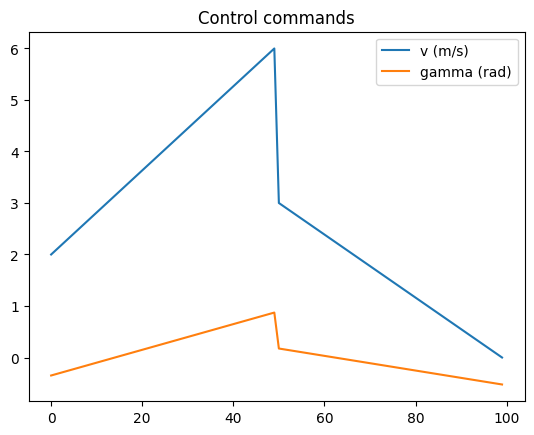

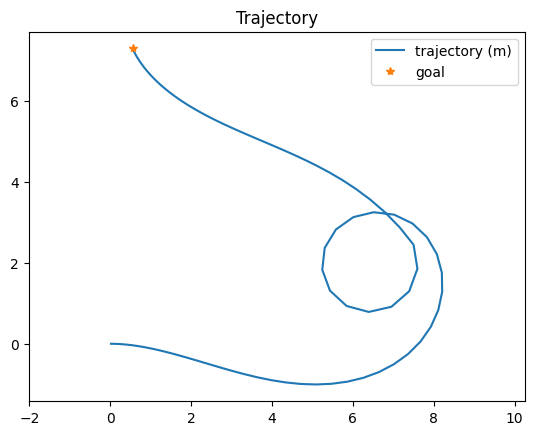

<Figure size 600x600 with 0 Axes>

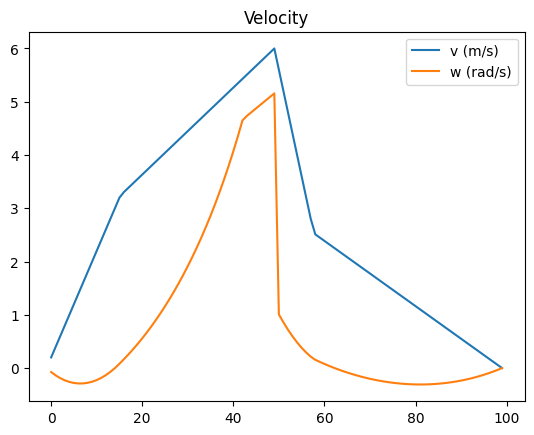

In [57]:
# Create command actions
velocity = np.hstack((np.linspace(2, 6, 50), np.linspace(3, 0, 50)))
steering = np.hstack((np.linspace(-20, 50, 50), np.linspace(10, -30, 50)))
steering = np.radians(steering)

# Create bicycle model
bike = BicycleModel()

# Execute commands using bicycle model and store the result
controls = []
states = []

for v, s in zip(velocity, steering):
    controls.append([v, s])
    bike.kinematics(v, s)
    states.append(bike.q)

plot_results(controls, states)

### Exercise 2: Move to a point controller

Now that the kinematics model for a bicycle-like vehicle is implemented, let's try to control it to move to a point ($x$, $y$).


This is a basic controller to reach a point:

$$
\nu_d = K_v \sqrt{(x_g - x)^2 + (y_g - y)}
$$

$$
\theta_d = \tan^{-1}\frac{y_g - y}{x_g - x}
$$

$$
\gamma_d = K_h \text{wrap\_angle}(\theta_d - \theta)
$$

Where $K_v > 0$ and $K_h > 0$ and $\text{goal} = [x_g~y_g]$

The *move to point* controller should follow an interface similar to:

```python
def move_to_point(state, goal, Kv, Kh):
    ...
    return v_d, gamma_d
```

where:
* `state` is the current state of the robot (i.e., $[x~y~\theta~v~w]$),
* `goal` is the $[x_g~y_g]$ position that the robot must reach
* `Kv` is a proportional gain for the forward velocity
* `Kh` is a proportional gain for the angular velocity
* `[v_d, gamma_d]` are the command actions that the controller requests to the robot to reach the `goal`.

Complete the following function:

In [58]:
def move_to_point(bike, goal, Kv=0.5, Kh=0.2):
    """ Computes the control command to move from current position to goal.
    @type  bike: BicycleModel
    @param bike: model containing current state (q) as well as maximum velocity and steering parameters

    @type  goal: ndarray or list
    @param goal: ndarray/list containing x, y position

    @type  Kv: float
    @param Kv: Proportional gain for velocity control command

    @type  Kh: float
    @param Kh: Proportional gain for steering control command

    @rtype: float, float
    @return: Desired velocity and steering commands to reach goal from current position
    """
    # Current state
    x, y, theta, v, w = bike.q

    # Goal position
    xg, yg = goal

    # Calculate distance to goal
    distance = np.sqrt((xg - x) ** 2 + (yg - y) ** 2)

    # Calculate desired velocity based on distance to goal
    v_d = Kv * distance

    # Calculate desired heading angle
    theta_d = wrap_angle(np.arctan2(yg - y, xg - x))

    # Calculate desired steering angle
    gamma_d = Kh * (theta_d - theta)

    return v_d, gamma_d


Test the function `move_to_point` you have implemented by executing the following code.

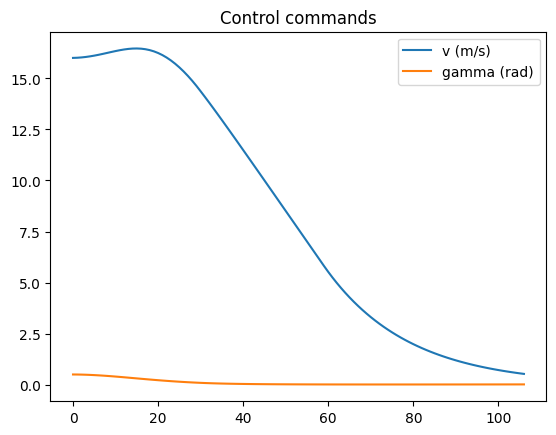

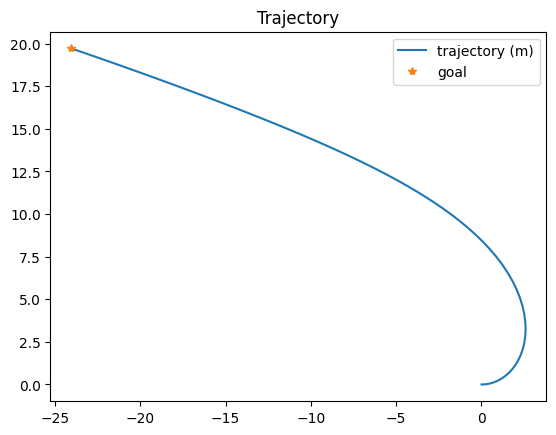

<Figure size 600x600 with 0 Axes>

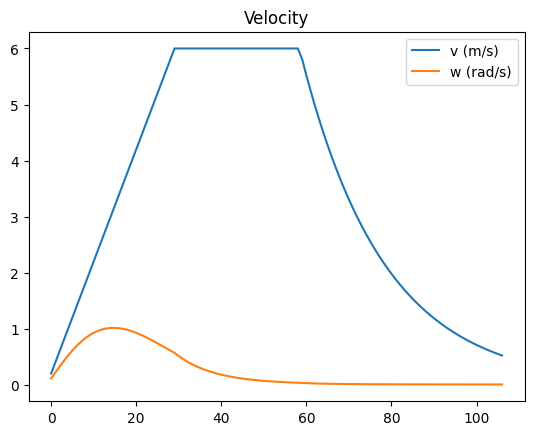

In [59]:
goal = np.array([-25.0, 20.0])
bike = BicycleModel()
max_error = 1.0

inputs = []
states = []

# Move towards the goal until within max_error
while np.linalg.norm(goal - bike.q[0:2]) > max_error:
    v_d, gamma_d = move_to_point(bike, goal)
    bike.kinematics(v_d, gamma_d)  # Update the bike state
    inputs.append([v_d, gamma_d])
    states.append(bike.q.copy())  # Store a copy of the current state

plot_results(inputs, states)

### Exercise 3: Move to a pose controller

For some applications it is important to have a controller that drives a vehicle not only to a point but to a pose (i.e., [$x_g$ $y_g$ $\theta_g$]). This is not always possible, but for the bicycle model there is a controller that allows to do that if the `goal` to reach is in front of the vehicle.

According to the following figure ([source](https://link.springer.com/book/10.1007/978-3-642-20144-8))

<img src="http://eia.udg.edu/~npalomer/imgs/as/bicycle_model2.png" width=450/>

the bicycle model can be represented using polar coordinates as follows:

$$
\rho = \sqrt{\Delta_x ^2 + \Delta_y ^2}
$$
$$
\alpha = \tan^{-1}\frac{\Delta_y}{\Delta_x} - \theta
$$
$$
\beta = \theta_g - \theta - \alpha
$$

being:

* `goal`: $[x_g~y_g~\theta_g$],
* vehicle `state`: $[x~y~\theta]$,
* $\Delta_x$ = $x_g - x$
* $\Delta_y$ = $y_g - y$
* $\rho$ the distance from the vehicle to the `goal`,
* $\beta$ the angle of the goal vector with respect to the world frame, and
* $\alpha$ the angle of the goal vector with respect to the vehicle frame.

The following linear control law is able to drive the robot to a unique equilibrium point (see the demonstration [here](https://link.springer.com/book/10.1007/978-3-642-20144-8)):

$$
\nu_d = k_\rho \rho
$$

$$
\gamma_d = k_\alpha \alpha + k_\beta \beta
$$

if the following conditions hold:

$
-\pi/2 < \alpha < \pi/2
$

and

$
k_\rho > 0,~ k_\beta < 0,~ k_\alpha - k_\rho > 0
$

Complete the following function to implement the proposed pose controller:

In [60]:
import numpy as np

def wrap_angle(angle):
    """Wraps an angle to the range [-pi, pi].
    @type  angle: float
    @param angle: Angle in radians
    @rtype: float
    @return: Wrapped angle in the range [-pi, pi]
    """
    return np.arctan2(np.sin(angle), np.cos(angle))
def move_to_pose(bike, goal, Kp=0.5, Ka=1.0, Kb=-0.5):
    """ Computes the control command to move from current position to goal pose.
    @type  bike: BicycleModel
    @param bike: model containing current state (q) as well as maximum velocity and steering parameters

    @type  goal: ndarray or list
    @param goal: ndarray/list containing x, y, theta pose

    @type  Kp: float
    @param Kp: Proportional gain for velocity contral command, Kp > 0

    @type  Ka: float
    @param Ka: Proportional gain for steering contral command, Ka - Kp > 0

    @type  Kb: float
    @param Kb: Proportional gain for steering contral command, Kb < 0

    @rtype: float, float
    @return: Desired velocity and steering commands to reach the goal
    """
    # Given conditions
    if Kp <= 0 or Ka <= Kp or Kb >= 0:
        raise ValueError("Invalid gains: Kp must be > 0, Ka must be > Kp, and Kb must be < 0")

    # Current state
    x, y, theta, v, w = bike.q

    # Goal position
    xg, yg, theta_g = goal

    # Calculate Δx and Δy
    del_x = xg - x
    del_y = yg - y

    # Calculate distance ρ to the goal
    rho = np.sqrt(del_x ** 2 + del_y ** 2)

    # Calculate angles α and β
    alpha = wrap_angle(np.arctan2(del_y, del_x) - theta)  # Angle of the goal vector with respect to the vehicle frame
    beta = wrap_angle(theta_g - theta - alpha)  # Angle of the goal vector with respect to the world frame

    # Check conditions for control law
    if -np.pi / 2 < alpha < np.pi / 2:
        # Compute desired velocity and steering angle
        v_d = Kp * rho  # Linear velocity command
        gamma_d = Ka * alpha + Kb * beta  # Steering angle command

        return v_d, gamma_d
    else:
        # If α is out of bounds, stop moving
        return 0.0, 0.0  # Stop the vehicle


Goal pose reached at (25.11, 20.22), -91.0º


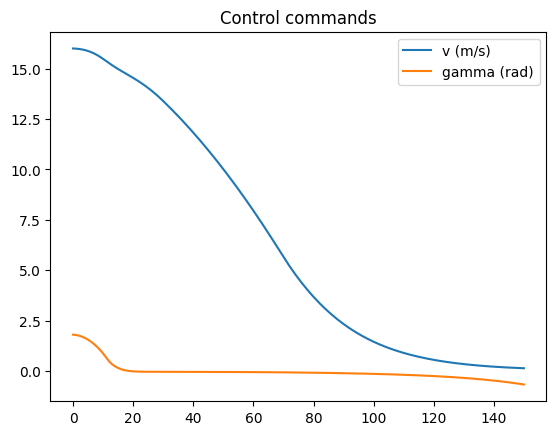

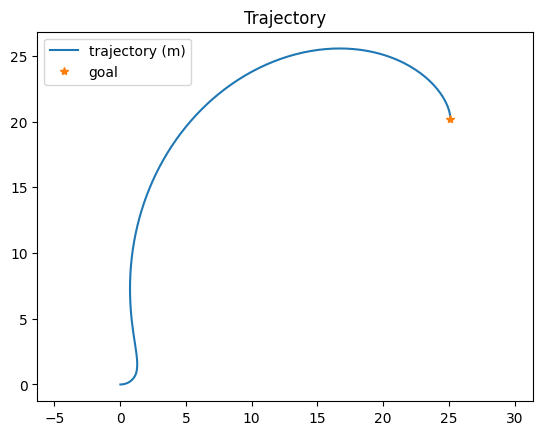

<Figure size 600x600 with 0 Axes>

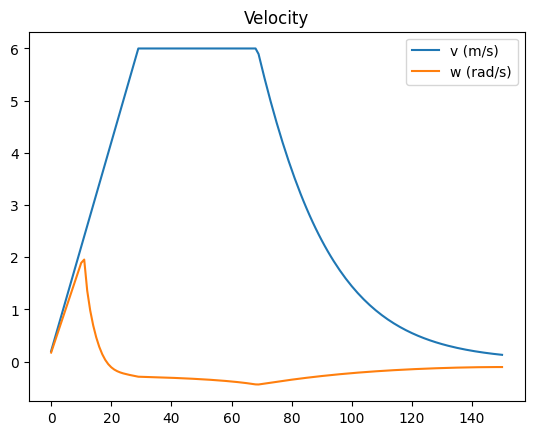

In [61]:
goal = np.array([25.0, 20.0, -np.pi/2])
bike = BicycleModel()
max_error = 0.25

inputs = []
states = []
v_d = 0

while np.linalg.norm(goal[0:2] - bike.q[0:2]) > max_error and v_d >= 0:
    v_d, gamma_d = move_to_pose(bike, goal)
    bike.kinematics(v_d, gamma_d)
    inputs.append([v_d, gamma_d])
    states.append(bike.q)

print("Goal pose reached at ({}, {}), {}º".format(np.round(bike.q[0],2), np.round(bike.q[1],2), np.round(np.degrees(bike.q[2])),2))
plot_results(inputs, states)

## Deliverable

Upload this Python Interactive Notebook fully completed through the Moodel platform before the deadline.
You can submit this lab up to 7 days late. However, you will be deducted 1 point if you submit it from 1 minute to 23h 59 minutes late, 2 points if you submit it from 24h to 47h 59 minutes late, etc.

Make sure that all cells can be executed.